# Motorcars

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline


## Laden

In [3]:
df = pd.read_csv('./mtcars.csv')

## Exploration

In [4]:
df.shape

(32, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


* Bedeutung der Spalten
  * model = Name
  * mpg = Miles per Gallon
  * cyl = Anzahl der Zylinder
  * displacement = Hubraum
  * hp = PS
  * drat = Achsenübersetzung
  * wt = Gewicht
  * qsec = "Quarter Mile Time"
  * vs = Motortyp, 0=V-Shaped, 1 = normal
  * am = Gangschaltung, 0=automatisch, 1=manuell
  * gear = Anzahl Gänge ohne Rückwärtsgang
  * carb = Anzahl der Vergaser (= carburetors)

* Ergebnis
  * Fast alles numerisch
  * Kandidaten Kategorien
    * cyl, vs, am und gear, carb
    * Model

In [6]:
df['model'].nunique()

32

* model ist nicht sinnvoll kategorisierbar, hat ja soviele Werte wie der gesamte Datensatz

In [7]:
category_candidates = ('cyl', 'vs', 'am', 'gear', 'carb')
for column in category_candidates:
    print(f'{column} has {df[column].nunique()} values')


cyl has 3 values
vs has 2 values
am has 2 values
gear has 3 values
carb has 6 values


* Ergebnis
  * cyl, vs, am, gear, carb sind kategorisierbar
  

In [8]:
for column in category_candidates:
    df[column] = pd.Categorical(df[column])
df.info()    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   model   32 non-null     object  
 1   mpg     32 non-null     float64 
 2   cyl     32 non-null     category
 3   disp    32 non-null     float64 
 4   hp      32 non-null     int64   
 5   drat    32 non-null     float64 
 6   wt      32 non-null     float64 
 7   qsec    32 non-null     float64 
 8   vs      32 non-null     category
 9   am      32 non-null     category
 10  gear    32 non-null     category
 11  carb    32 non-null     category
dtypes: category(5), float64(5), int64(1), object(1)
memory usage: 2.8+ KB


## Potenzielle Zusammenhänge

## PairGrid mit Scatterplot

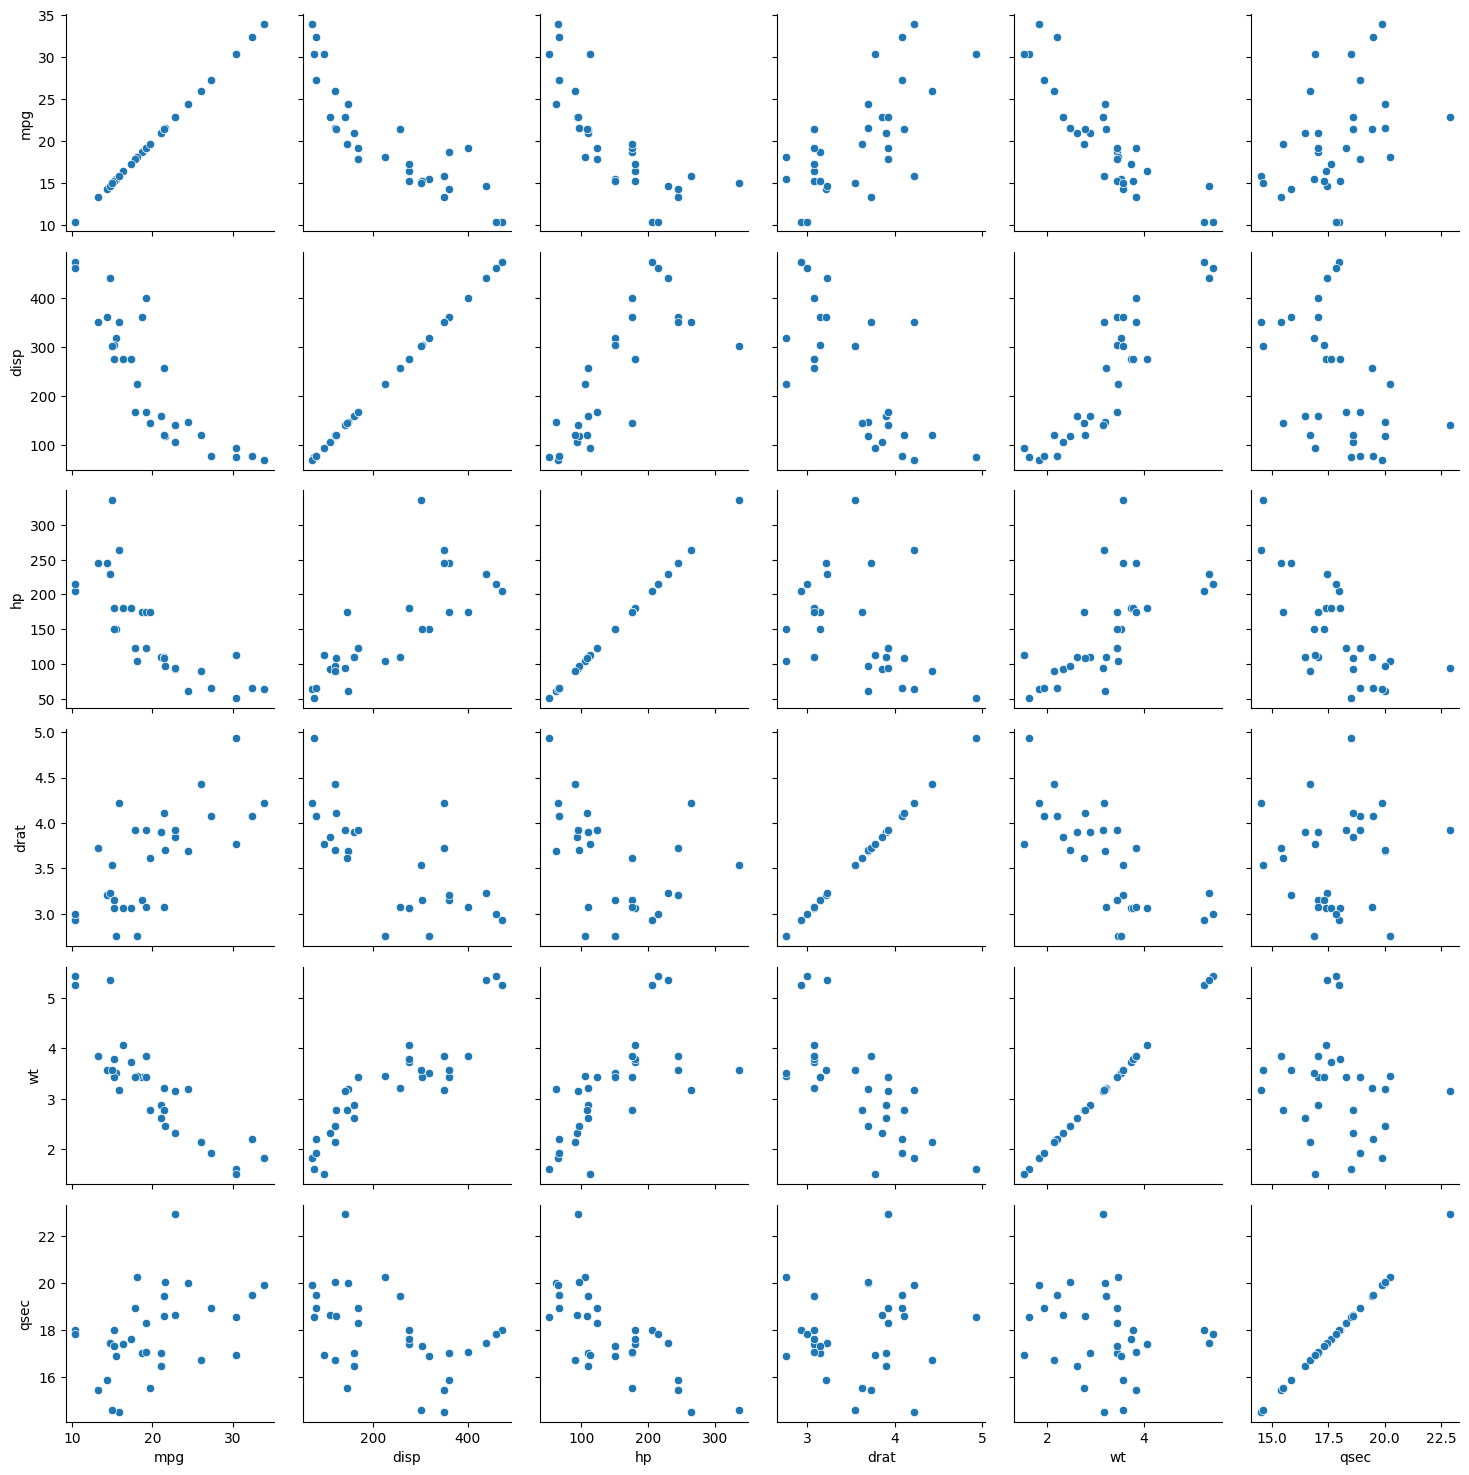

In [9]:
plots = sns.PairGrid(df)
plots.map(sns.scatterplot)

## Heatmap

<Axes: >

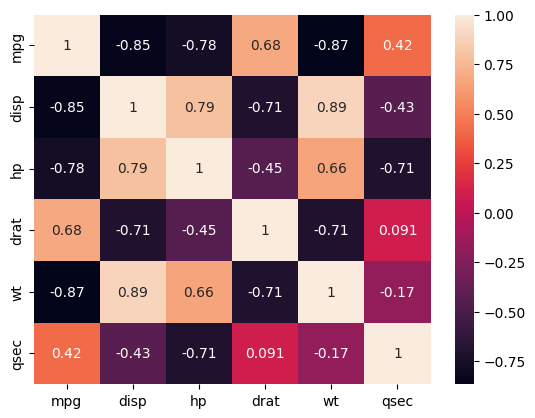

In [10]:
sns.heatmap(df[df.select_dtypes(include='number').columns].corr(), annot=True)

## Kategorien

<Axes: >

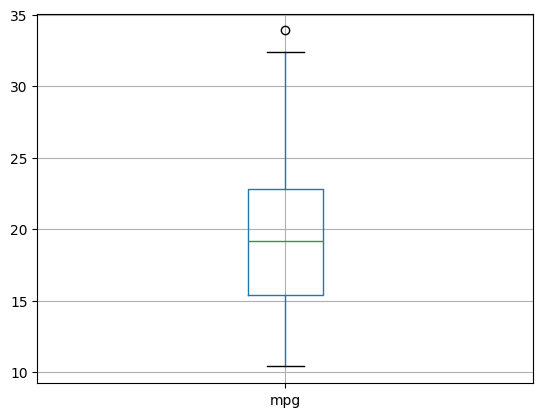

In [11]:
df.boxplot('mpg')

<Axes: title={'center': 'mpg'}, xlabel='am'>

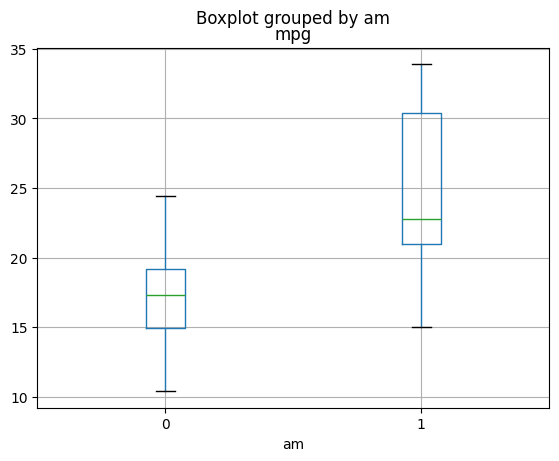

In [12]:
df.boxplot('mpg', by='am')

<Axes: title={'center': 'mpg'}, xlabel='cyl'>

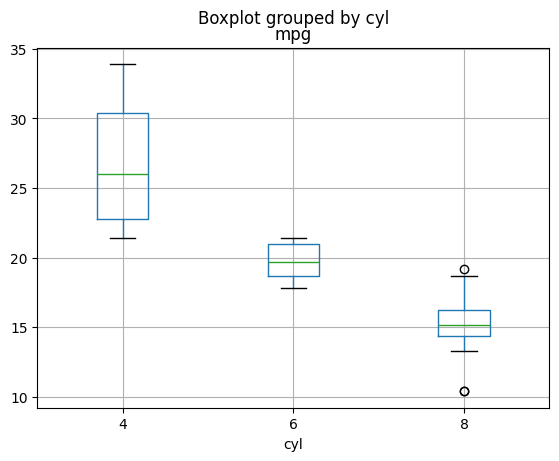

In [13]:
df.boxplot('mpg', by='cyl')

<Axes: title={'center': 'wt'}, xlabel='vs'>

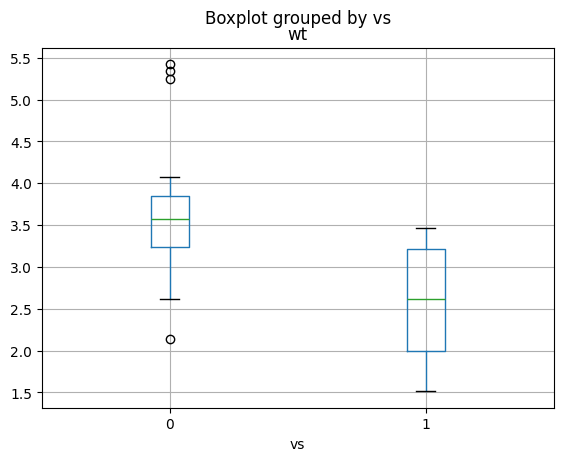

In [14]:
df.boxplot('wt', by='vs')

## Analyse

### Deskriptive Statistik

In [15]:
df.describe()

,mpg,disp,hp,drat,wt,qsec
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,20.090625,230.721875,146.687500,3.596563,3.217250,17.848750
std,6.026948,123.938694,68.562868,0.534679,0.978457,1.786943
min,10.400000,71.100000,52.000000,2.760000,1.513000,14.500000
25%,15.425000,120.825000,96.500000,3.080000,2.581250,16.892500
50%,19.200000,196.300000,123.000000,3.695000,3.325000,17.710000
75%,22.800000,326.000000,180.000000,3.920000,3.610000,18.900000
max,33.900000,472.000000,335.000000,4.930000,5.424000,22.900000


<Axes: ylabel='Density'>

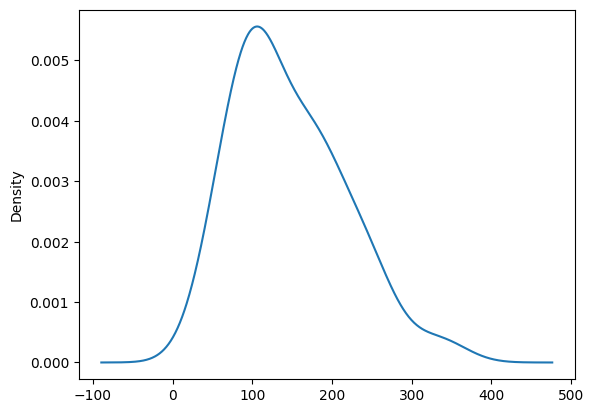

In [ ]:
df['mpg'].plot(kind='density')

In [ ]:
f'Kurtosis: {df["mpg"].kurt():.4}'

'Kurtosis: -0.02201'

In [18]:
f'Skewness: {df["mpg"].skew():.4}'

'Skewness: 0.6724'

## Regressionsanalyse

In [31]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


<Axes: xlabel='wt', ylabel='mpg'>

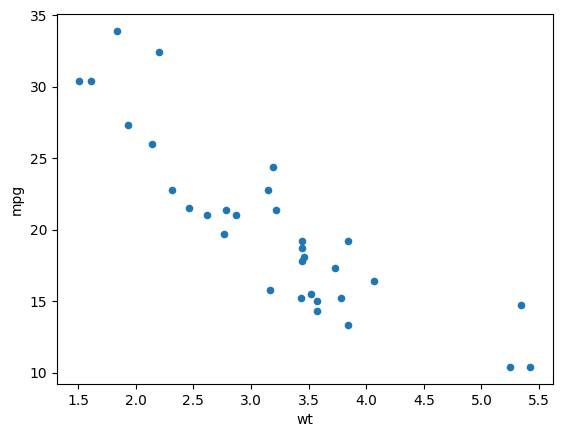

In [32]:
df.plot(kind='scatter', x='wt', y='mpg')

In [33]:
from sklearn import linear_model

regression_model = linear_model.LinearRegression()
x_axis = pd.DataFrame((df['wt']))
y_axis = df['mpg']
regression_model.fit(X=x_axis, y=y_axis)
print(f'Achsenabschnitt: {regression_model.intercept_:.2f}')
print(f'Steigung: {regression_model.coef_[0]:.2f}')

Achsenabschnitt: 37.29
Steigung: -5.34


In [34]:
print(f'Score: {regression_model.score(X=x_axis, y=y_axis):.2f}')


Score: 0.75


* Vorhergesagte Werte der Ausgleichsgerade an den Messpunkten

In [35]:
predicted_mpg = regression_model.predict(X=x_axis)
predicted_mpg

array([23.28261065, 21.9197704 , 24.88595212, 20.10265006, 18.90014396,
       18.79325453, 18.20536265, 20.23626185, 20.45004071, 18.90014396,
       18.90014396, 15.53312687, 17.3502472 , 17.08302362,  9.22665041,
        8.29671236,  8.71892561, 25.52728871, 28.65380458, 27.47802083,
       24.11100374, 18.47258623, 18.92686632, 16.76235533, 16.73563297,
       26.94357367, 25.847957  , 29.19894068, 20.34315128, 22.48093991,
       18.20536265, 22.4274952 ])

* Abweichungen pro Messpunkt

In [36]:
residuals_mpg = df['mpg'] - predicted_mpg
residuals_mpg

0    -2.282611
1    -0.919770
2    -2.085952
3     1.297350
4    -0.200144
5    -0.693255
6    -3.905363
7     4.163738
8     2.349959
9     0.299856
10   -1.100144
11    0.866873
12   -0.050247
13   -1.883024
14    1.173350
15    2.103288
16    5.981074
17    6.872711
18    1.746195
19    6.421979
20   -2.611004
21   -2.972586
22   -3.726866
23   -3.462355
24    2.464367
25    0.356426
26    0.152043
27    1.201059
28   -4.543151
29   -2.780940
30   -3.205363
31   -1.027495
Name: mpg, dtype: float64

In [37]:
residuals_mpg.describe()

count    3.200000e+01
mean    -8.215650e-15
std      2.996352e+00
min     -4.543151e+00
25%     -2.364709e+00
50%     -1.251956e-01
75%      1.409561e+00
max      6.872711e+00
Name: mpg, dtype: float64

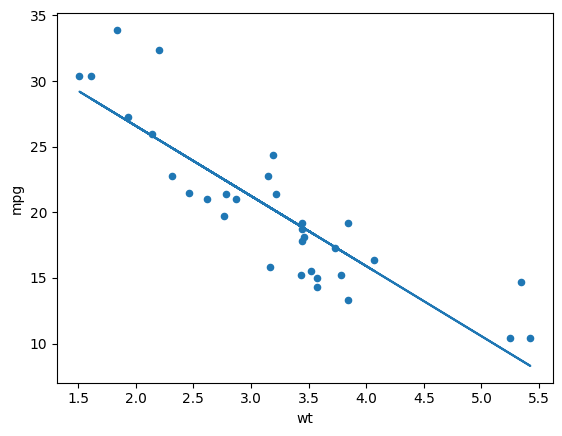

In [38]:
df.plot(kind='scatter', x='wt', y='mpg')
plt.plot(df['wt'].to_numpy(), predicted_mpg)

* Probability und Probability Plot

((array([-2.02511189, -1.62590278, -1.38593914, -1.20666642, -1.05953591,
         -0.93235918, -0.81872017, -0.71478609, -0.6180591 , -0.52680137,
         -0.43973827, -0.35589149, -0.27447843, -0.19484777, -0.11643566,
         -0.03873405,  0.03873405,  0.11643566,  0.19484777,  0.27447843,
          0.35589149,  0.43973827,  0.52680137,  0.6180591 ,  0.71478609,
          0.81872017,  0.93235918,  1.05953591,  1.20666642,  1.38593914,
          1.62590278,  2.02511189]),
  array([-4.54315128, -3.90536265, -3.72686632, -3.46235533, -3.20536265,
         -2.97258623, -2.78093991, -2.61100374, -2.28261065, -2.08595212,
         -1.88302362, -1.10014396, -1.0274952 , -0.9197704 , -0.69325453,
         -0.20014396, -0.0502472 ,  0.152043  ,  0.29985604,  0.35642633,
          0.86687313,  1.17334959,  1.20105932,  1.29734994,  1.74619542,
          2.10328764,  2.34995929,  2.46436703,  4.16373815,  5.98107439,
          6.42197917,  6.87271129])),
 (np.float64(3.0327797489458974),
  n

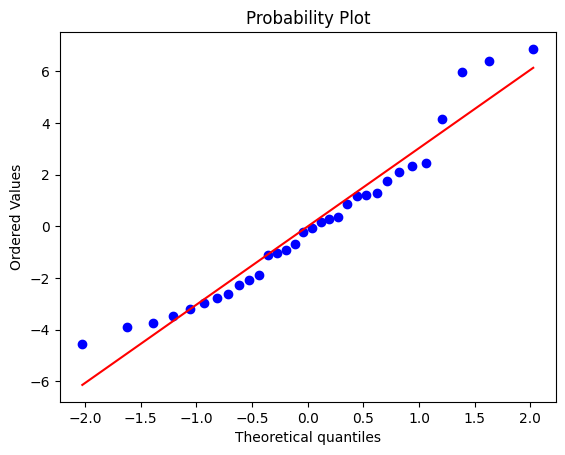

In [39]:
import scipy.stats as stats
stats.probplot(residuals_mpg, dist='norm', plot=plt)

### Leistung

Achsenabschnitt: 30.10
Steigung: -0.07
Score: 0.60


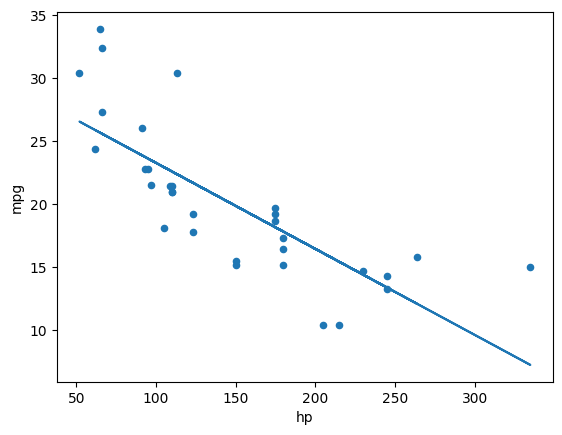

In [41]:
regression_model = linear_model.LinearRegression()
x_axis = pd.DataFrame(df['hp'])
regression_model.fit(X=x_axis, y=y_axis)
print(f'Achsenabschnitt: {regression_model.intercept_:.2f}')
print(f'Steigung: {regression_model.coef_[0]:.2f}')
print(f'Score: {regression_model.score(X=x_axis, y=y_axis):.2f}')
predicted_mpg = regression_model.predict(X=x_axis)
df.plot(kind='scatter', x='hp', y='mpg')
plt.plot(df['hp'].to_numpy(), predicted_mpg)

### Hubraum

Achsenabschnitt: 29.60
Steigung: -0.04
Score: 0.72


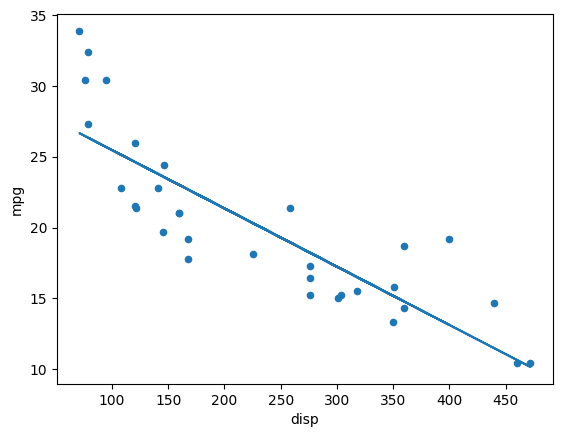

In [42]:
regression_model = linear_model.LinearRegression()
x_axis = pd.DataFrame(df['disp'])
regression_model.fit(X=x_axis, y=y_axis)
print(f'Achsenabschnitt: {regression_model.intercept_:.2f}')
print(f'Steigung: {regression_model.coef_[0]:.2f}')
print(f'Score: {regression_model.score(X=x_axis, y=y_axis):.2f}')
predicted_mpg = regression_model.predict(X=x_axis)
df.plot(kind='scatter', x='disp', y='mpg')
plt.plot(df['disp'].to_numpy(), predicted_mpg)

## Exkurs: Programmierung

In [49]:
def do_linear_regression(name, x, y):
    x_axis = pd.DataFrame(df[x])
    y_axis = df[y]
    regression_model = linear_model.LinearRegression()
    regression_model.fit(X=x_axis, y=y_axis)
    print(f'Linear Regression for {name}')
    print(f'Achsenabschnitt: {regression_model.intercept_:.2f}')
    print(f'Steigung: {regression_model.coef_[0]:.2f}')
    print(f'Score: {regression_model.score(X=x_axis, y=y_axis):.2f}')
    predicted_mpg = regression_model.predict(X=x_axis)
    df.plot(kind='scatter', x=x, y=y)
    plt.plot(df[x].to_numpy(), predicted_mpg)

Linear Regression for Miles per Gallon vs Weight
Achsenabschnitt: 37.29
Steigung: -5.34
Score: 0.75


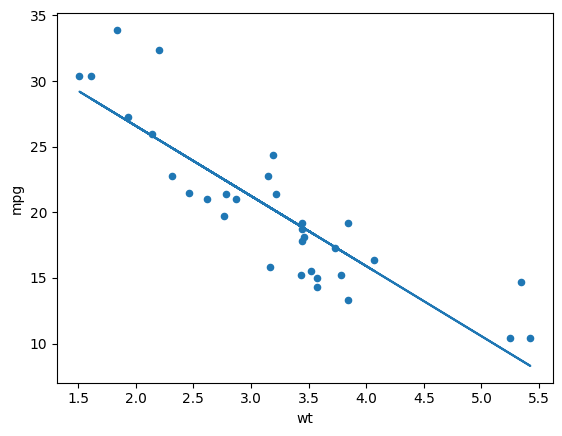

In [50]:
do_linear_regression('Miles per Gallon vs Weight','wt', 'mpg')

Linear Regression for Miles per Gallon vs Horsepower
Achsenabschnitt: 30.10
Steigung: -0.07
Score: 0.60


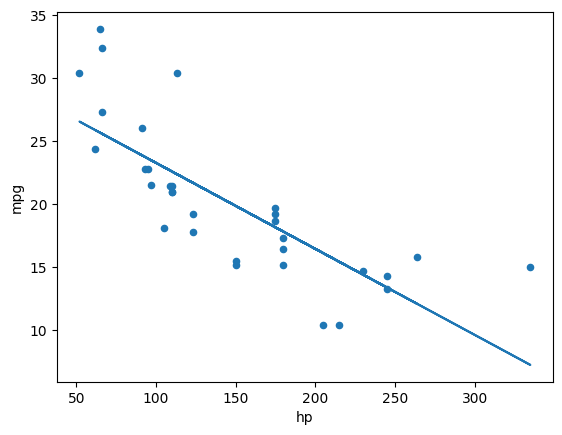

In [51]:
do_linear_regression('Miles per Gallon vs Horsepower','hp', 'mpg')

Linear Regression for Miles per Gallon vs Dispersion
Achsenabschnitt: 29.60
Steigung: -0.04
Score: 0.72


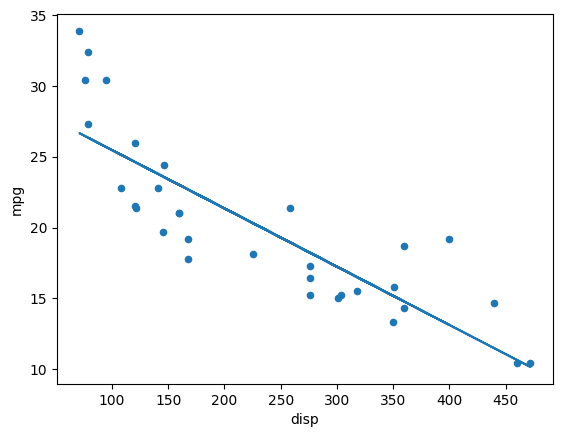

In [52]:
do_linear_regression('Miles per Gallon vs Dispersion','disp', 'mpg')

Linear Regression for Dispersion vs Horsepower
Achsenabschnitt: 45.73
Steigung: 0.44
Score: 0.63


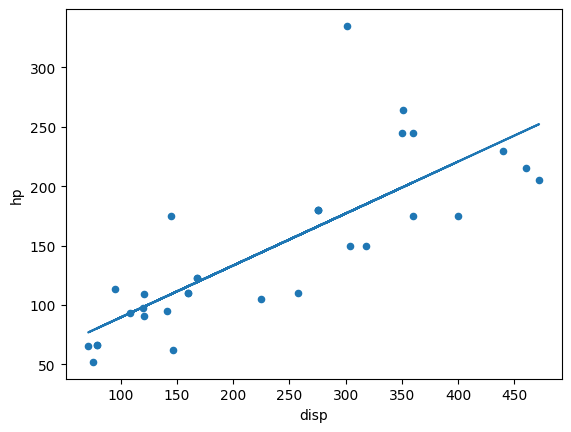

In [53]:
do_linear_regression('Dispersion vs Horsepower','disp', 'hp')